In [55]:
import xarray as xr
import pandas as pd
import numpy as np
import os
from glob import glob

# Directory where all acpcp files are stored
data_dir = os.path.expanduser('~/sandbox/data/20C_PRECIP')
file_pattern = os.path.join(data_dir, 'acpcp.*.nc')
files = sorted(glob(file_pattern))

# Define Shanghai bounding box (approx)
lat_bounds = (30.8, 31.5)
lon_bounds = (120.8, 121.5)  # dataset uses 0-360

# Target calendar range
target_mmdd = pd.date_range('2000-08-20', '2000-08-31').strftime('%m-%d')

results = []

for file in files:
    try:
        ds = xr.open_dataset(file)
        ds = ds.sel(lat=slice(*lat_bounds), lon=slice(*lon_bounds))
        # Format time to MM-DD
        mmdd = ds['time'].dt.strftime('%m-%d')
        sel = mmdd.isin(target_mmdd)
        ds_sel = ds.sel(time=ds.time[sel])
        
        # Mean rainfall over Shanghai region
        daily = ds_sel['acpcp'].mean(dim=['lat', 'lon'])
        
        # Collect data
        for t, val in zip(daily['time'].values, daily.values):
            results.append({'date': pd.to_datetime(t), 'rainfall_kgm2': float(val)})
    
    except Exception as e:
        print(f"Error with file {file}: {e}")
        continue

# Combine into DataFrame
df = pd.DataFrame(results)
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day

In [57]:
# After creating df (as in the previous script)
# Group by year and sum rainfall
annual_totals = df.groupby('year')['rainfall_kgm2'].sum().reset_index()
annual_totals.rename(columns={'rainfall_kgm2': 'rainfall_kgm2_annual'}, inplace=True)

In [60]:
df

,date,rainfall_kgm2,year,month,day
0,1806-08-20,1.237875,1806,8,20
1,1806-08-21,1.338375,1806,8,21
2,1806-08-22,1.456125,1806,8,22
3,1806-08-23,0.854500,1806,8,23
4,1806-08-24,1.187500,1806,8,24
...,...,...,...,...,...
2515,2015-08-27,0.162500,2015,8,27
2516,2015-08-28,0.337500,2015,8,28
2517,2015-08-29,0.362500,2015,8,29
2518,2015-08-30,0.175000,2015,8,30


In [52]:
annual_totals[annual_totals.year==1905]

,year,rainfall_kgm2_annual
99,1905,7.657


In [53]:
np.median(annual_totals.rainfall_kgm2_annual)

7.7830625250935555

In [65]:
test = pd.read_csv('./xujiahui_aug2031_daily_rain.csv')

<Axes: >

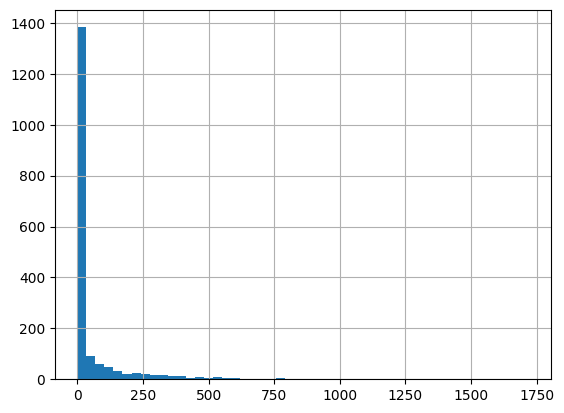

In [67]:
test.daily_acc_10thmm.hist(bins=50)

In [69]:
test[(test.Year==1905)]

,Year,Mon,Day,daily_acc_10thmm
372,1905,8,20,124
373,1905,8,21,366
374,1905,8,22,104
375,1905,8,23,5
376,1905,8,24,65
377,1905,8,25,0
378,1905,8,26,8
379,1905,8,27,0
380,1905,8,28,745
381,1905,8,29,135


In [73]:
from scipy import stats
stats.percentileofscore(test.daily_acc_10thmm, 745, kind='rank')

98.88888888888889